<a href="https://colab.research.google.com/github/victorventu/PI-DataScience/blob/Atividade-BigData/Atividade_do_Projeto_de_Extens%C3%A3o_An%C3%A1lise_e_Visualiza%C3%A7%C3%A3o_de_Dados_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Atividade do Projeto de Extensão - Análise e Visualização de Dados

**Objetivo da Atividade:**


Realizar a exploração inicial dos dados do projeto, aplicando técnicas de análise exploratória com Python (Pandas, Matplotlib e Seaborn) para compreender o cenário e auxiliar na tomada de decisão. A análise busca identificar padrões, tendências temporais, distribuições, correlações e possíveis valores discrepantes (outliers).

**Estudantes - Data Science 2026 - Unifeob**

- Caio H. S. Cruz
- Gabriel M. Freire
- Luis E. L. Silva
- Lanna G. G. Amaro
- Victor Venturini Neto

**A Base de Dados:**

A base de dados analisada (fca_vendas_estoque_mock.csv) simula um registro transações e o estoque da *F.C.A. Serviços Pecuários e Comércio de Produtos Veterinários Ltda.*, pois ainda não foi fornecido uma base de dados oficial pela empresa beneficiada.

- Colunas:

> Data_Venda: *Data em que a transação ocorreu. Fundamental para análises de séries temporais e identificação de sazonalidade.*

> ID_Produto: *Código de identificação único de cada item comercializado.*

> Categoria: *Classificação do produto vendido. Os itens estão divididos em quatro categorias principais:*

- Insumo

- Suplemento

- Vacina

- Medicamento

> Qtd_Vendida: *Volume de unidades comercializadas na transação.*

> Estoque_Atual: *Quantidade do produto restante armazenada no inventário no momento do registro. Permite analisar o fluxo de giro e reposição.*

> Preco_Unitario: *Valor financeiro cobrado por cada unidade do produto.*

> Temperatura_Media: *Temperatura climática ambiente (em graus) registrada no dia da venda. Variável ambiental essencial para verificar se as condições climáticas influenciam a demanda (por exemplo, picos de vendas de medicamentos ou vacinas em dias mais frios ou quentes).*

In [1]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df = pd.read_csv('/content/drive/MyDrive/Big Data/fca_vendas_estoque_mock.csv')

# Converti Data_Venda para o tipo datetime
df['Data_Venda'] = pd.to_datetime(df['Data_Venda'])

print(df.head())

  Data_Venda ID_Produto    Categoria  Qtd_Vendida  Estoque_Atual  \
0 2026-06-13   PROD_002       Vacina           62            188   
1 2026-03-04   PROD_004  Medicamento           88            181   
2 2026-06-23   PROD_012       Vacina           89            261   
3 2026-01-09   PROD_001       Vacina           63            162   
4 2026-05-10   PROD_010       Vacina           56             46   

   Preco_Unitario  Temperatura_Media  
0          190.56               28.2  
1          189.39               23.8  
2          155.81               22.7  
3           70.29               22.7  
4          149.09               16.4  


In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Data_Venda         5000 non-null   datetime64[ns]
 1   ID_Produto         5000 non-null   object        
 2   Categoria          5000 non-null   object        
 3   Qtd_Vendida        5000 non-null   int64         
 4   Estoque_Atual      5000 non-null   int64         
 5   Preco_Unitario     5000 non-null   float64       
 6   Temperatura_Media  5000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(2)
memory usage: 273.6+ KB
None


In [7]:
print(df.describe())

                       Data_Venda  Qtd_Vendida  Estoque_Atual  Preco_Unitario  \
count                        5000  5000.000000    5000.000000     5000.000000   
mean   2026-04-01 21:30:14.400000    49.786000     200.121000      134.058128   
min           2026-01-01 00:00:00     0.000000       0.000000       20.020000   
25%           2026-02-15 00:00:00    33.000000     145.000000       75.725000   
50%           2026-04-04 00:00:00    50.000000     200.000000      131.250000   
75%           2026-05-16 00:00:00    66.000000     255.000000      193.455000   
max           2026-06-29 00:00:00   148.000000     474.000000      249.990000   
std                           NaN    24.329944      80.132222       66.690676   

       Temperatura_Media  
count        5000.000000  
mean           25.008820  
min             5.400000  
25%            21.700000  
50%            25.000000  
75%            28.200000  
max            44.300000  
std             4.982962  


In [8]:
print(df.isnull().sum())

Data_Venda           0
ID_Produto           0
Categoria            0
Qtd_Vendida          0
Estoque_Atual        0
Preco_Unitario       0
Temperatura_Media    0
dtype: int64


In [9]:
print(df.duplicated().sum())

0


## Análise de Padrões:
- **Distribuição por Categoria:**
Visualizar qual tipo de produto tem em maior quantidade na base

> Insumo

> Suplemento

>Vacina

>Medicamento

- **Densidade e Distribuição Numérica:**
Entender como os preços e as quantidades vendidas estão distribuídos

> Distribuição de Preço Unitário

> Distribuição de Quantidade Vendida

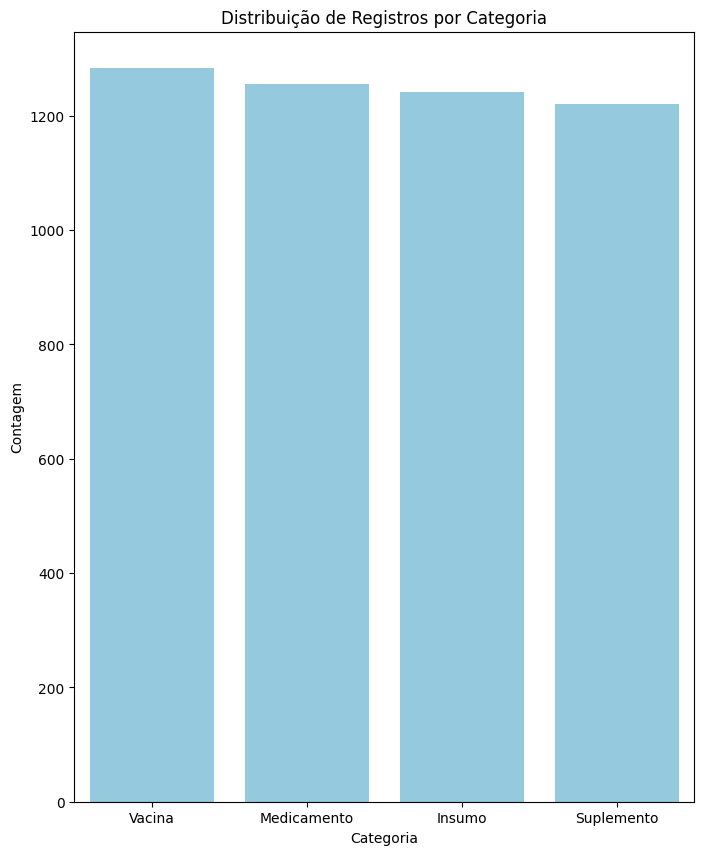

In [17]:
#Distribuição por Categoria

plt.figure(figsize=(8, 10))
sns.countplot(x='Categoria', data=df, color='skyblue')
plt.title('Distribuição de Registros por Categoria')
plt.ylabel('Contagem')
plt.show()

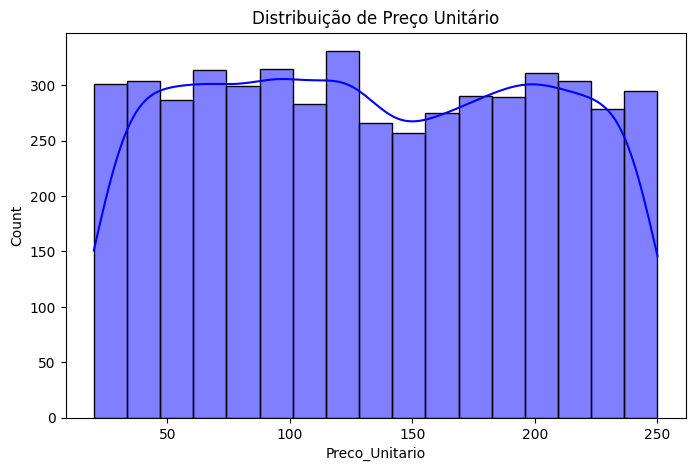

In [23]:
# Densidade e Distribuição Numérica
# Preço Unitário

plt.figure(figsize=(8, 5))
sns.histplot(df['Preco_Unitario'], kde=True, color='blue')
plt.title('Distribuição de Preço Unitário')
plt.show()

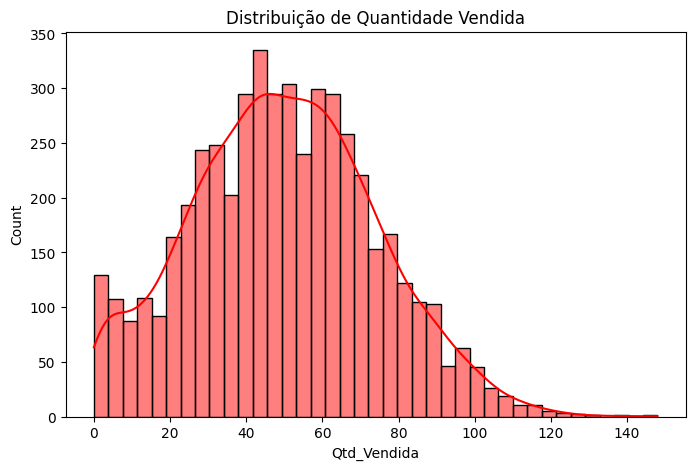

In [29]:
# Densidade e Distribuição Numérica
# Quantidade Vendida

plt.figure(figsize=(8, 5))
sns.histplot(df['Qtd_Vendida'], kde=True, color='red')
plt.title('Distribuição de Quantidade Vendida')
plt.show()

## Identificação de Valores Discrepantes (Outliers)

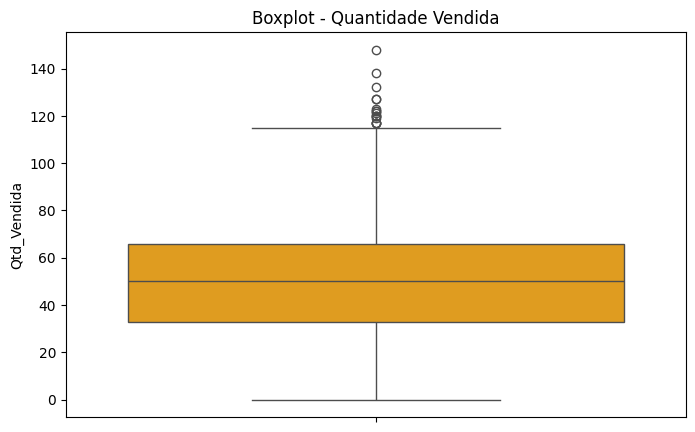

In [27]:
# Quantidade Vendida

plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Qtd_Vendida'], color='orange')
plt.title('Boxplot - Quantidade Vendida')
plt.show()

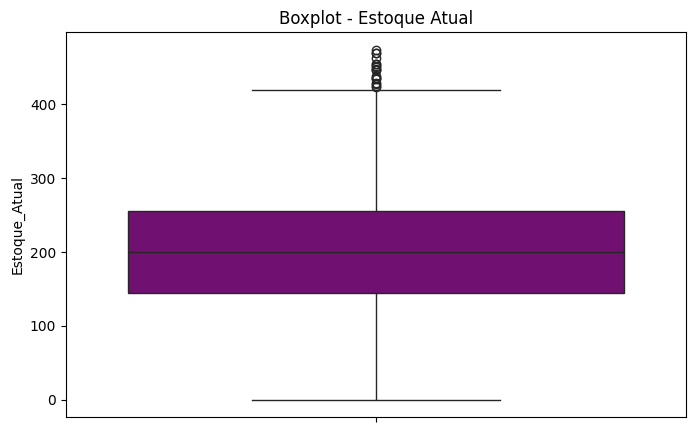

In [30]:
# Estoque Atual

plt.figure(figsize=(8, 5))
sns.boxplot(y=df['Estoque_Atual'], color='purple')
plt.title('Boxplot - Estoque Atual')
plt.show()

## Correlação, Relação e Tendência

- **Matriz de Correlação:** Avaliar como Temperatura_Media afeta a Qtd_Vendida, ou se há relação entre Preco_Unitario e o volume de saída.

- **Relação (Categoria vs Estoque/Vendas):**
Ajuda a identificar se alguma categoria específica sofre com estoque muito baixo ou vende mais em média.

- **Tendência**:
Gráfico de linha mostrando a evolução das vendas ao longo do tempo para tomar decisões.

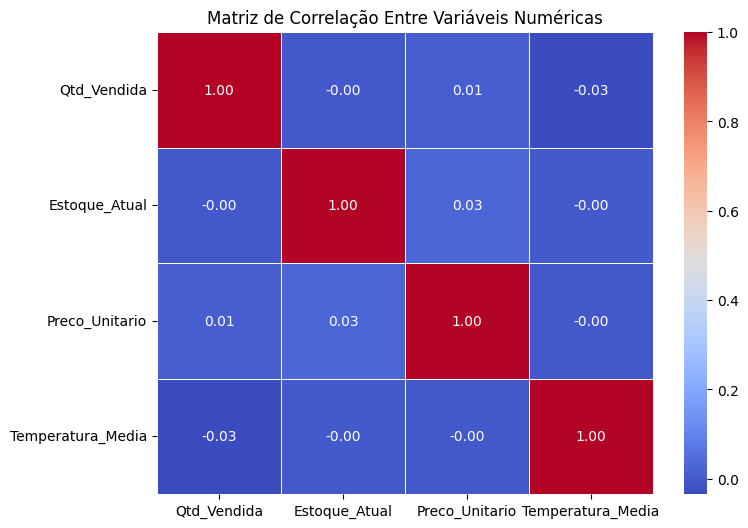

In [32]:
# Matriz de Correlação

numerical_df = df.select_dtypes(include=['number'])
corr = numerical_df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlação Entre Variáveis Numéricas')
plt.show()

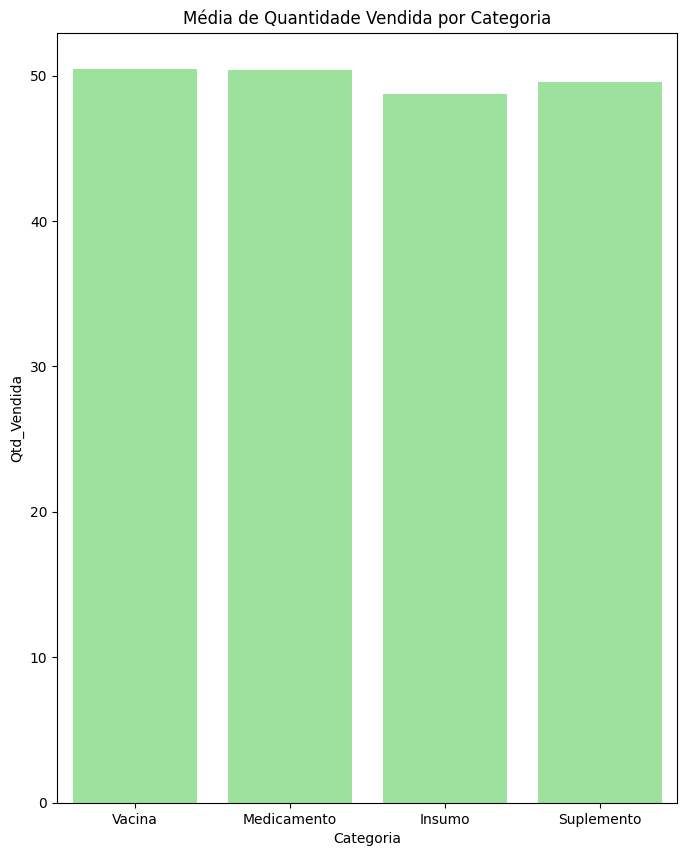

In [49]:
# Relação

plt.figure(figsize=(8, 10))
sns.barplot(x='Categoria', y='Qtd_Vendida', data=df, errorbar=None, color='lightgreen')
plt.title('Média de Quantidade Vendida por Categoria')
plt.show()

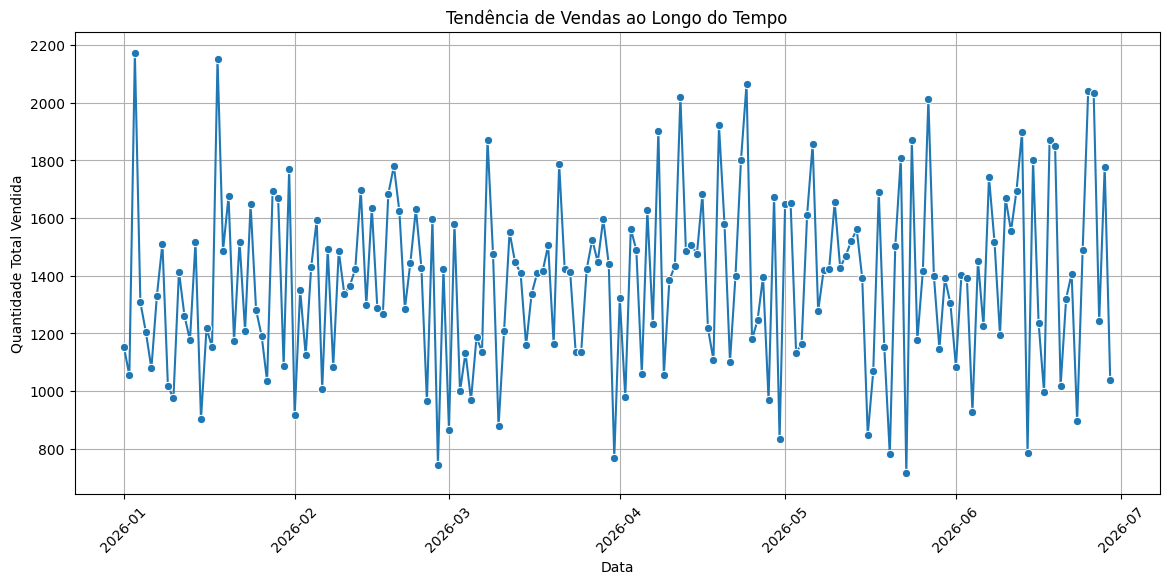

In [45]:
plt.figure(figsize=(14, 6))
# venda_por_dia agrupa as vendas de cada dia e soma elas para resultar na quantidade vendida
vendas_por_dia = df.groupby('Data_Venda')['Qtd_Vendida'].sum().reset_index()

sns.lineplot(x='Data_Venda', y='Qtd_Vendida', data=vendas_por_dia, marker='o')
plt.title('Tendência de Vendas ao Longo do Tempo')
plt.xlabel('Data')
plt.ylabel('Quantidade Total Vendida')
plt.xticks(rotation=45)
plt.grid(True)
plt.show()

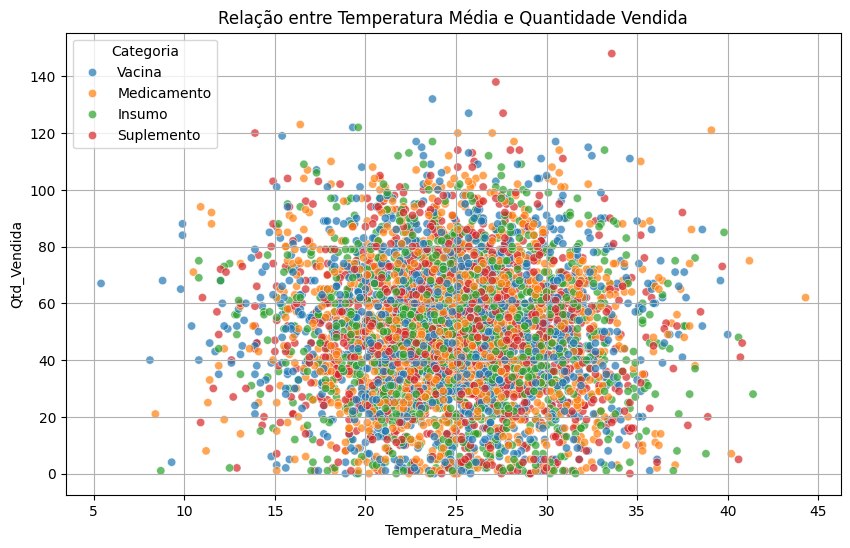

In [47]:
# Gráfico em Scatterplot para tentar analisar se há uma relação entre temperatura média dos dias e a quantidade de produtos vendidos

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Temperatura_Media', y='Qtd_Vendida', hue='Categoria', data=df, alpha=0.7)
plt.title('Relação entre Temperatura Média e Quantidade Vendida')
plt.grid(True)
plt.show()